### Lab IV: Linear Models
### Answer all three sets of questions

#### Turn in one python file for the three computation questions and one text file for Q0

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
3. Can linear regression be used for classification? Explain why, or why not.
4. If you have a high accuracy on training but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 
5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

### Answers:

1. A model is linear if it is linear in the coefficients. That means the prediction is a sum of variables times coefficients, plus possibly an intercept.

2. The coefficient on a dummy variable depends on whether you include an intercept. Without an intercept, each dummy coefficient is the mean of that category. With an intercept, one category is taken out, the intercept is the mean of the omitted category, and each dummy coefficient is the difference from that of the omitted category.

3. Linear regression is not a good model for classification because it predicts continuous values, so predicted values can be below 0 or above 1. Classification problems are better handled by models like logistic regression.

4. If training performance is high but testing performance is low, then the model is probably overfitting. If the residuals show a clear pattern, then the model may also be missing important nonlinear relationships or variables.

5. Two ways to include nonlinear relationships are to add nonlinear features, such as polynomial terms, and use a model pipeline that first transforms the features nonlinearly and then fits a linear model.

6. The intercept is the predicted value of y when all numeric variables are 0, and the observation is in the left-out dummy category. A slope coefficient gives the change in predicted y for a one-unit increase in that variable (holding the other variables fixed).

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

Q1.1
                    Price  Review Scores Rating
Neighborhood                                   
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


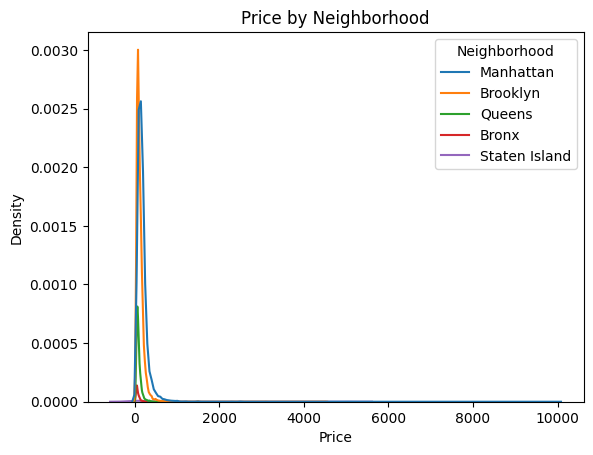

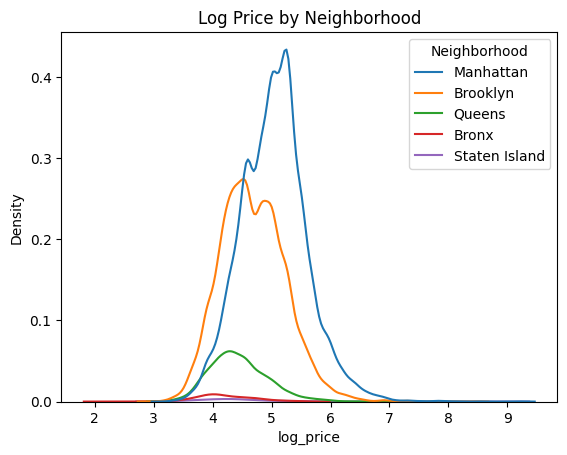

Q1.2
        variable  coefficient
0          Bronx    75.276498
1       Brooklyn   127.747378
2      Manhattan   183.664286
3         Queens    96.857233
4  Staten Island   146.166667
Q1.3
Intercept: 75.27649769585331
        variable  coefficient
0       Brooklyn    52.470881
1      Manhattan   108.387789
2         Queens    21.580735
3  Staten Island    70.890169
Q1.4
R-squared: 0.08230721172544131
RMSE: 106.28986886521714
                     variable  coefficient
0        Review Scores Rating     1.027509
1       Neighborhood_Brooklyn    52.049106
2      Neighborhood_Manhattan   109.333624
3         Neighborhood_Queens    21.624392
4  Neighborhood_Staten Island    88.979703
Q1.5
R-squared: 0.08534318021973553
RMSE: 106.11390582635056
                         variable  coefficient
0            Review Scores Rating     1.016811
1           Neighborhood_Brooklyn    60.473177
2          Neighborhood_Manhattan   123.429970
3             Neighborhood_Queens    28.382998
4      Neighborh

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# Q1

df = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
df = df.rename(columns={"Neighbourhood ": "Neighborhood"})

# Q1.1
print("Q1.1")
print(df.groupby("Neighborhood")[["Price", "Review Scores Rating"]].mean())

sns.kdeplot(data=df, x="Price", hue="Neighborhood")
plt.title("Price by Neighborhood")
plt.show()

df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="log_price", hue="Neighborhood")
plt.title("Log Price by Neighborhood")
plt.show()


# Q1.2
print("Q1.2")

y = df["Price"]
X = pd.get_dummies(df["Neighborhood"], dtype="int")

regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(X, y)

results = pd.DataFrame({"variable": regr.feature_names_in_, "coefficient": regr.coef_})
print(results)


# Q1.3
print("Q1.3")

y = df["Price"]
X = pd.get_dummies(df["Neighborhood"], drop_first=True, dtype="int")

regr = linear_model.LinearRegression()
regr.fit(X, y)

print("Intercept:", regr.intercept_)
results = pd.DataFrame({"variable": regr.feature_names_in_, "coefficient": regr.coef_})
print(results)


# Q1.4
print("Q1.4")

Y = df["Price"]
X = df.loc[:, ["Review Scores Rating", "Neighborhood"]]
X = pd.get_dummies(X, drop_first=True, dtype="int")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

print("R-squared:", r2_score(Y_test, predicted))
print("RMSE:", mean_squared_error(Y_test, predicted) ** .5)

results = pd.DataFrame({"variable": regr.feature_names_in_, "coefficient": regr.coef_})
print(results)


# Q1.5
print("Q1.5")

Y = df["Price"]
X = df.loc[:, ["Review Scores Rating", "Neighborhood", "Property Type"]]
X = pd.get_dummies(X, drop_first=True, dtype="int")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

print("R-squared:", r2_score(Y_test, predicted))
print("RMSE:", mean_squared_error(Y_test, predicted) ** .5)

results = pd.DataFrame({"variable": regr.feature_names_in_, "coefficient": regr.coef_})
print(results)

print(df.groupby("Property Type")["Price"].mean().sort_values(ascending=False))

### Written Answers

Q1.2

* Without an intercept, each borough dummy coefficient equals the mean price for that borough.

Q1.3

* With an intercept, one borough is left out. The intercept is the mean price for the left-out borough, and each dummy coefficient is the difference from that borough.

Q1.6

* The Review Scores Rating coefficient changes because part 5 controls for Property Type in addition to Neighborhood.

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

Q2.1
<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    int64
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(6), str(6)
memory usage: 91.6 KB
None
Q2.2
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: floa

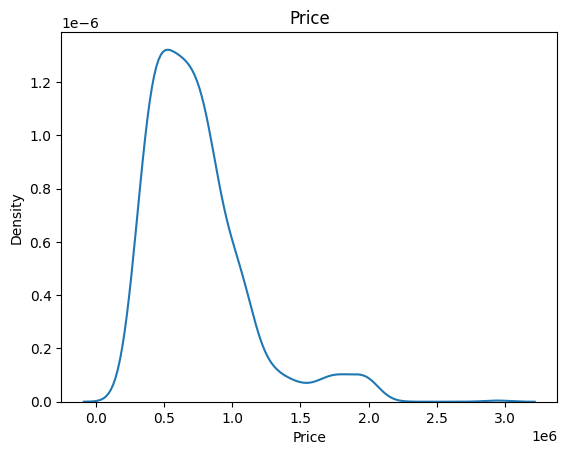

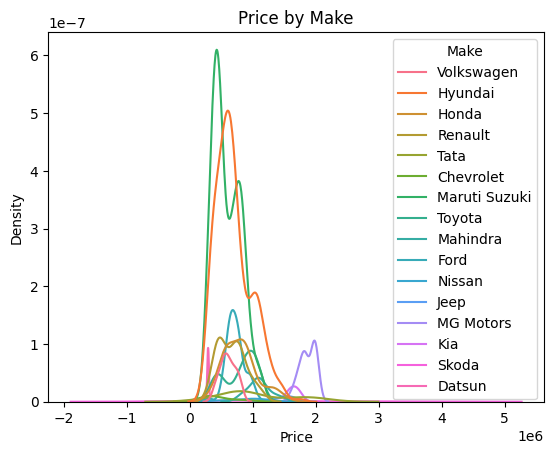

Q2.4 numeric only
Train R-squared: 0.3181523649769129
Train RMSE: 311873.66993715224
Test R-squared: 0.26315648916459955
Test RMSE: 272862.86314408487
Q2.4 categorical only
Test R-squared: 0.6773697455498338
Test RMSE: 180554.92767033342
Q2.4 joint model
Test R-squared: 0.7986329550231914
Test RMSE: 142643.17558847828
Q2.5
Degree: 1
Test R-squared: 0.26315648916459955
Test RMSE: 272862.86314408487
Degree: 2
Test R-squared: 0.335054140689347
Test RMSE: 259208.92041255246
Degree: 3
Test R-squared: 0.32999123430910715
Test RMSE: 260193.8591713551
Degree: 4
Test R-squared: 0.31895982181044913
Test RMSE: 262327.10549129156
Degree: 5
Test R-squared: 0.31495526694011255
Test RMSE: 263097.2241937694
Degree: 6
Test R-squared: 0.337693665969483
Test RMSE: 258693.93951821438
Degree: 7
Test R-squared: 0.1427600096583106
Test RMSE: 294312.0282375636
Degree: 8
Test R-squared: 0.09270776524341051
Test RMSE: 302782.239745794
Q2.6


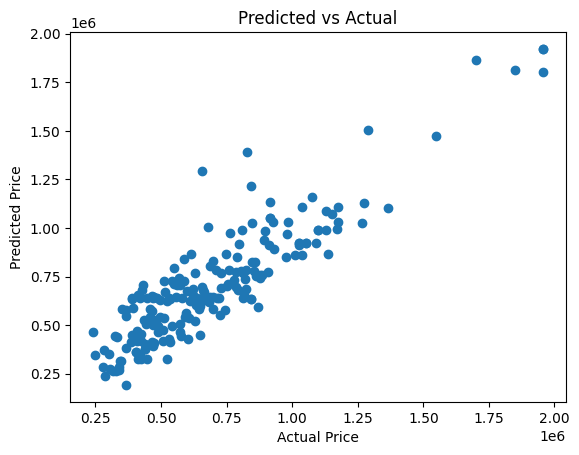

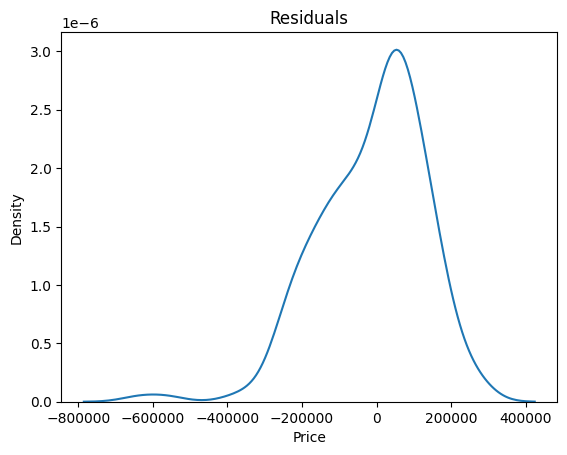

In [18]:
df = pd.read_csv("cars_hw.csv")
df["No_of_Owners"] = df["No_of_Owners"].str[0].astype(int)

# Q2.1
print("Q2.1")
print(df.info())


# Q2.2
print("Q2.2")
print(df["Price"].describe())
print(df.groupby("Make")["Price"].describe())

sns.kdeplot(data=df, x="Price")
plt.title("Price")
plt.show()

sns.kdeplot(data=df, x="Price", hue="Make")
plt.title("Price by Make")
plt.show()


# Q2.3 and Q2.4: numeric only
print("Q2.4 numeric only")

Y = df["Price"]
X = df.loc[:, ["Make_Year", "Mileage_Run", "Seating_Capacity", "No_of_Owners"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)

predicted_train = regr.predict(X_train)
predicted_test = regr.predict(X_test)

print("Train R-squared:", r2_score(Y_train, predicted_train))
print("Train RMSE:", mean_squared_error(Y_train, predicted_train) ** .5)
print("Test R-squared:", r2_score(Y_test, predicted_test))
print("Test RMSE:", mean_squared_error(Y_test, predicted_test) ** .5)


# Q2.4: categorical only
print("Q2.4 categorical only")

Y = df["Price"]
X = df.loc[:, ["Make", "Color", "Body_Type", "Fuel_Type", "Transmission", "Transmission_Type"]]
X = pd.get_dummies(X, drop_first=True, dtype="int")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

print("Test R-squared:", r2_score(Y_test, predicted))
print("Test RMSE:", mean_squared_error(Y_test, predicted) ** .5)


# Q2.4: joint model
print("Q2.4 joint model")

Y = df["Price"]
X = df.loc[:, ["Make_Year", "Mileage_Run", "Seating_Capacity", "No_of_Owners",
               "Make", "Color", "Body_Type", "Fuel_Type", "Transmission", "Transmission_Type"]]
X = pd.get_dummies(X, drop_first=True, dtype="int")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)
predicted_joint = regr.predict(X_test)

print("Test R-squared:", r2_score(Y_test, predicted_joint))
print("Test RMSE:", mean_squared_error(Y_test, predicted_joint) ** .5)


# Q2.5
print("Q2.5")

Y = df["Price"]
X = df.loc[:, ["Make_Year", "Mileage_Run", "Seating_Capacity", "No_of_Owners"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

for d in range(1, 9):
    expander = PolynomialFeatures(degree=d, include_bias=False)
    Z_train = expander.fit_transform(X_train)
    Z_test = expander.transform(X_test)
    names = expander.get_feature_names_out()

    Z_train = pd.DataFrame(data=Z_train, columns=names)
    Z_test = pd.DataFrame(data=Z_test, columns=names)

    regr = linear_model.LinearRegression()
    regr.fit(Z_train, Y_train)
    predicted = regr.predict(Z_test)

    print("Degree:", d)
    print("Test R-squared:", r2_score(Y_test, predicted))
    print("Test RMSE:", mean_squared_error(Y_test, predicted) ** .5)


# Q2.6
print("Q2.6")

residuals = Y_test - predicted_joint

plt.scatter(Y_test, predicted_joint)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()

sns.kdeplot(residuals)
plt.title("Residuals")
plt.show()

### Written Answers

Q2.4

* The joint model performs best.

Q2.5

* The polynomial models performed best around degree 6. Higher degrees can reduce test performance.

Q2.6

* The predicted-versus-actual plot shows a positive relationship, and the residuals are centered around 0.

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

Q3.2
count    279769.000000
mean         39.172256
std          78.230356
min           0.000000
25%           0.000000
50%           0.000000
75%          32.000000
max         337.000000
Name: Electric Range, dtype: float64
                           count        mean         std    min     25%  \
Make                                                                      
ACURA                      356.0    0.000000    0.000000    0.0    0.00   
ALFA ROMEO                 104.0   33.000000    0.000000   33.0   33.00   
AUDI                      5937.0   36.742294   71.103243    0.0    0.00   
AZURE DYNAMICS               3.0   56.000000    0.000000   56.0   56.00   
BENTLEY                     10.0   33.000000   13.097922   17.0   21.50   
BMW                      11607.0   26.994831   33.177289    0.0    0.00   
BRIGHTDROP                  51.0    0.000000    0.000000    0.0    0.00   
CADILLAC                  2434.0    1.272391    6.708921    0.0    0.00   
CHEVROLET               

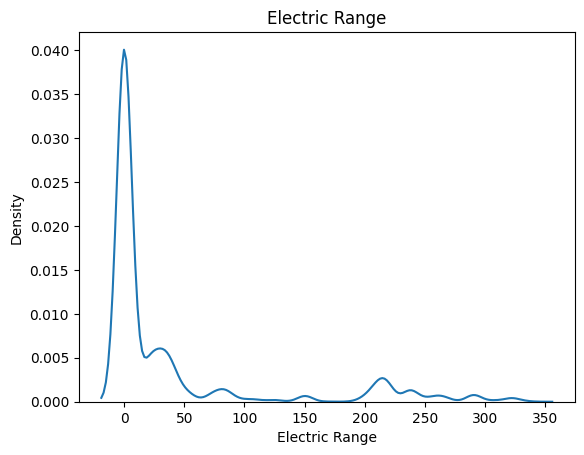

Q3 numeric model
RMSE: 64.95584364949374
R-squared: 0.29817361833826095
Q3 categorical model
RMSE: 23.826777319784718
R-squared: 0.90556698717838
Q3 joint model
RMSE: 22.800062157226947
R-squared: 0.9135300325092451
Q3 polynomial model
RMSE: 63.57324708477065
R-squared: 0.3277326458969885


In [ ]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

df = df[["Electric Range", "Model Year", "Make",
         "Electric Vehicle Type",
         "Clean Alternative Fuel Vehicle (CAFV) Eligibility"]]

df = df.dropna()

# Q3.2
print("Q3.2")
print(df["Electric Range"].describe())
print(df.groupby("Make")["Electric Range"].describe())

sns.kdeplot(data=df, x="Electric Range")
plt.title("Electric Range")
plt.show()


# Q3 numeric model
print("Q3 numeric model")

Y = df["Electric Range"]
X = df.loc[:, ["Model Year"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)
predicted1 = regr.predict(X_test)

print("RMSE:", mean_squared_error(Y_test, predicted1) ** .5)
print("R-squared:", r2_score(Y_test, predicted1))


# Q3 categorical model
print("Q3 categorical model")

Y = df["Electric Range"]
X = df.loc[:, ["Make", "Electric Vehicle Type",
               "Clean Alternative Fuel Vehicle (CAFV) Eligibility"]]
X = pd.get_dummies(X, drop_first=True, dtype="int")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)
predicted2 = regr.predict(X_test)

print("RMSE:", mean_squared_error(Y_test, predicted2) ** .5)
print("R-squared:", r2_score(Y_test, predicted2))


# Q3 joint model
print("Q3 joint model")

Y = df["Electric Range"]
X = df.loc[:, ["Model Year", "Make",
               "Electric Vehicle Type",
               "Clean Alternative Fuel Vehicle (CAFV) Eligibility"]]
X = pd.get_dummies(X, drop_first=True, dtype="int")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)
predicted3 = regr.predict(X_test)

print("RMSE:", mean_squared_error(Y_test, predicted3) ** .5)
print("R-squared:", r2_score(Y_test, predicted3))


# Q3 polynomial model
print("Q3 polynomial model")

Y = df["Electric Range"]
X = df.loc[:, ["Model Year"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.20, random_state=40)

expander = PolynomialFeatures(degree=2, include_bias=False)
Z_train = expander.fit_transform(X_train)
Z_test = expander.transform(X_test)
names = expander.get_feature_names_out()

Z_train = pd.DataFrame(data=Z_train, columns=names)
Z_test = pd.DataFrame(data=Z_test, columns=names)

regr = linear_model.LinearRegression()
regr.fit(Z_train, Y_train)
predicted4 = regr.predict(Z_test)

print("RMSE:", mean_squared_error(Y_test, predicted4) ** .5)
print("R-squared:", r2_score(Y_test, predicted4))

### Written Answers

Q3.1

* I used the Electric Vehicle Population Data dataset.

Q3.2

* My dependent variable is Electric Range.

Q3.4 / conclusion

* The joint model performed best.

Q3.5 / Q3.6

* The categorical variables explain much more of the variation in Electric Range than Model Year alone, which shows that choosing strong predictors matters a lot for regression performance.

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


In [ ]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
